# Make QC figures

In [1]:
here::i_am("thesis/QC.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [2]:
io$basedir

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut"

In [17]:
args = list()
args$meta_RNA = file.path(io$basedir, 'results/rna/doublet_detection/sample_metadata_after_doublets.txt.gz')
args$meta_ATAC = file.path(io$basedir, 'results/atac/archR/qc/sample_metadata_after_qc.txt.gz')
args$sce = io$rna.sce

dir.create(file.path(io$basedir, 'thesis/qc/'), showWarnings = F, recursive = T)

In [10]:
sample_rename = gsub('KO', 'KD', gsub('rep', '', opts$sample2alias))
sample_order = c(
    'D2.5_WT_1',
    'D2.5_WT_2',
    'D3_WT_1',
    'D3_WT_2',
    'D3_KD_1',
    'D3_KD_2',
    'D4.5_WT_1',
    'D4.5_KD_1'
)

sample_colors = c(
    'D2.5_WT_1' = '#000000',
    'D2.5_WT_2' = '#202020',
    'D3_WT_1' = '#414141',
    'D3_WT_2' = '#626262',
    'D3_KD_1' = '#8B0000',
    'D3_KD_2' = '#A22426',
    'D4.5_WT_1' = '#828282',
    'D4.5_KD_1' = '#B9484D'
)

In [11]:
meta_rna <- fread(args$meta_RNA) %>% 
  .[pass_rnaQC==TRUE & doublet_call==FALSE] %>% 
    .[,sample_clean := sample_rename[match(sample, names(sample_rename))]] %>% 
    .[,sample_clean := factor(sample_clean, levels = sample_order)]

In [14]:
meta_atac <- fread(args$meta_ATAC) %>% 
  .[pass_atacQC==TRUE & doublet_call==FALSE] %>% 
    .[,sample_clean := sample_rename[match(sample, names(sample_rename))]] %>% 
    .[,sample_clean := factor(sample_clean, levels = sample_order)]

In [15]:
# Define a custom theme
theme = theme(
  # axis.title = element_text(color = 'black', size = 7),
  axis.title = element_blank(),
  axis.text.x = element_text(angle=90, hjust=1, vjust=0.5, size=5, color = 'black'), 
  axis.text = element_text(size=5, color='black'),
  text = element_text(size=5),
  plot.margin = margin(0, 3, 0, 0),  # Adjust the margin around the plot
  plot.title = element_text(size=7, face='plain', hjust=0.5, vjust = -0.5),
  panel.border = element_rect(color='black', linewidth=0.5, fill = NA),
  panel.background = element_blank(),
  panel.grid.major = element_line(color = 'grey95'),
  axis.line = element_blank(),
  axis.ticks = element_line(linewidth=0.25, color = 'black'),
  legend.position = 'none'
)

# Create a list of common geoms
geoms <- list(
  geom_violin(linewidth = 0.1, aes(fill = sample_clean)),
  geom_boxplot(width = 0.2, linewidth = 0.1, outlier.shape = NA, fill = 'white'),
  scale_fill_manual(values = sample_colors) 
)

p_rna_reads = ggplot(meta_rna, aes(sample_clean, log(nCount_RNA))) + 
    geoms + 
    ggtitle('Log(# counts)') + 
    theme

p_rna_genes = ggplot(meta_rna, aes(sample_clean, log(nFeature_RNA))) + 
    geoms + 
    ggtitle('Log(# genes)') + 
    theme

p_rna_ribo = ggplot(meta_rna, aes(sample_clean, ribosomal_percent_RNA)) + 
    geoms + 
    ggtitle('% Ribo counts') + 
    theme

p_rna_mito = ggplot(meta_rna, aes(sample_clean, mitochondrial_percent_RNA)) + 
    geoms + 
    ggtitle('% Mito counts') + 
    theme
p_atac_frags = ggplot(meta_atac, aes(sample_clean, log(nFrags_atac))) + 
    geoms + 
    ggtitle('Log(# Fragments)') + 
    theme

p_atac_tss = ggplot(meta_atac, aes(sample_clean, TSSEnrichment_atac)) + 
    geoms + 
    ggtitle('TSS Enrichment') + 
    theme

options(repr.plot.height=7, repr.plot.width=25)
p1 = ggarrange(p_rna_reads, p_rna_genes, p_rna_mito, p_rna_ribo, p_atac_frags, p_atac_tss, nrow = 1, align = 'hv')


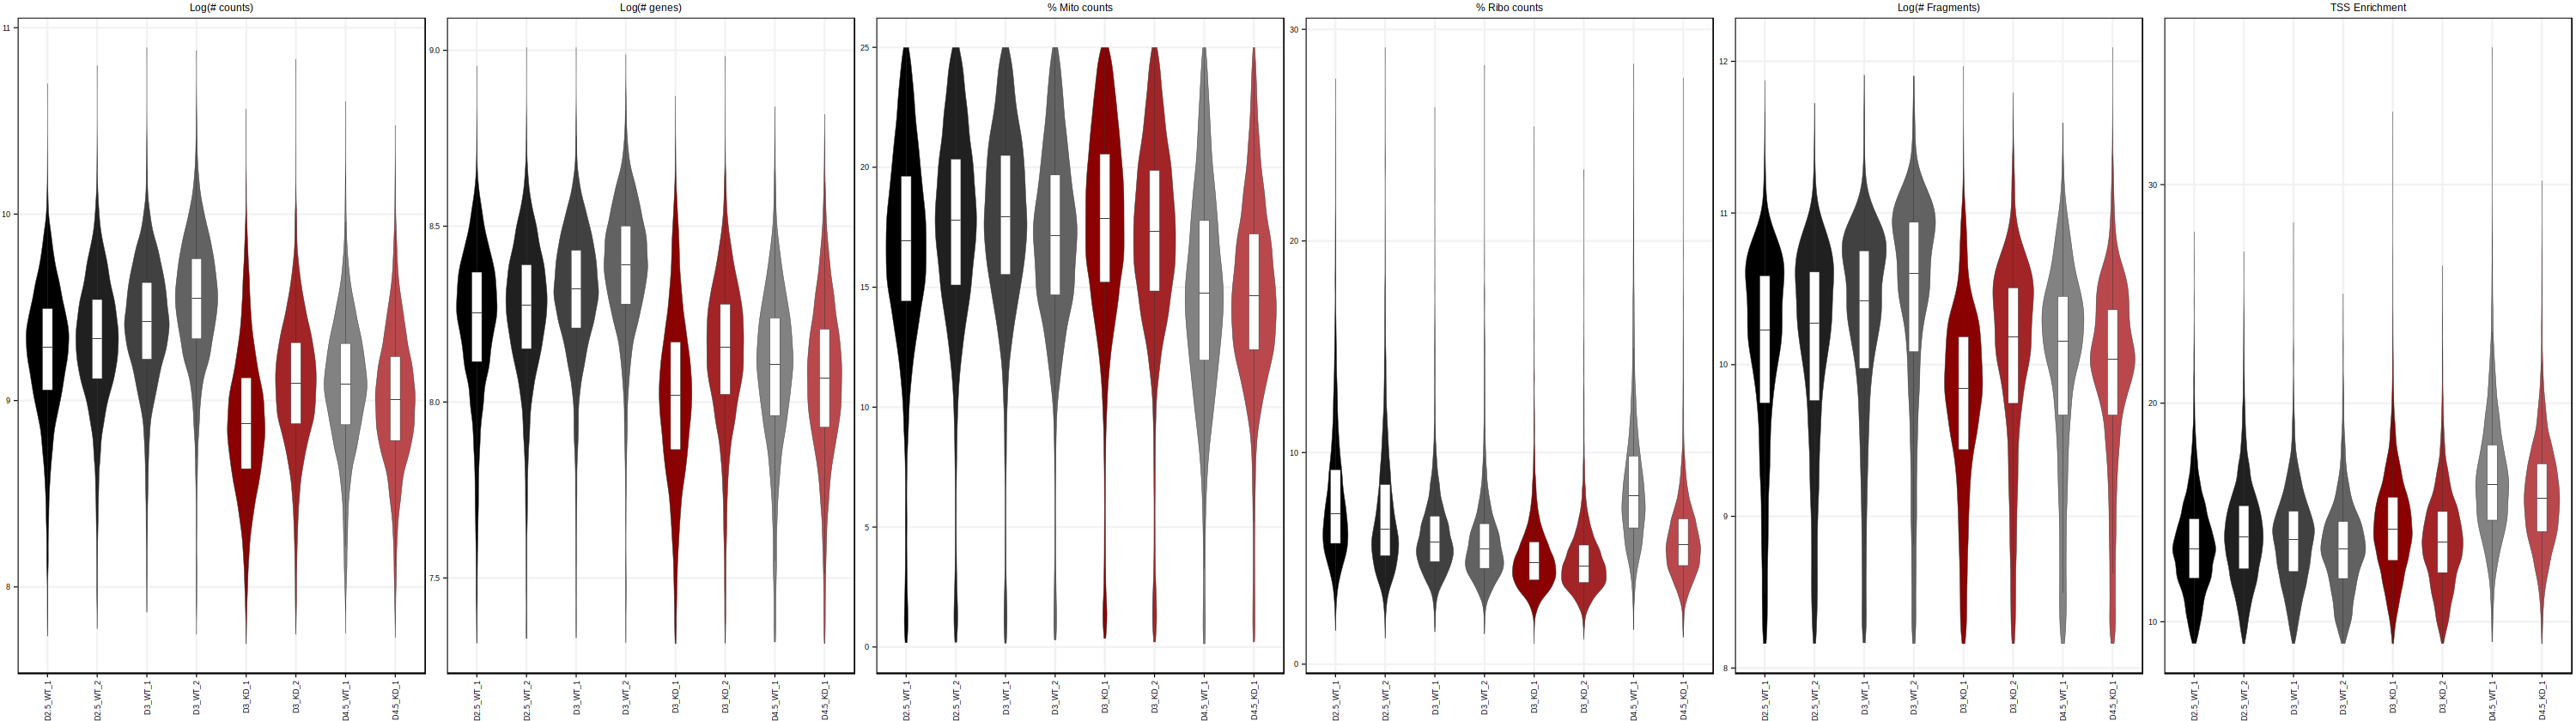

In [16]:
p1

In [20]:
TSS = fread(file.path(io$basedir, '/results/atac/archR/qc/qc_TSSenrichment.txt.gz')) %>% 
    .[,sample_clean := sample_rename[match(sample, names(sample_rename))]] %>% 
    .[,sample_clean := factor(sample_clean, levels = sample_order)] %>% 
    .[,genotype := factor(str_split(sample_clean, '_') %>% map_chr(2), levels = c('WT', 'KD'))]

In [21]:
FragmentSize = fread(file.path(io$basedir, '/results/atac/archR/qc/qc_FragmentSizeDistribution.txt.gz')) %>% 
    .[,sample_clean := sample_rename[match(sample, names(sample_rename))]] %>% 
    .[,sample_clean := factor(sample_clean, levels = sample_order)] %>% 
    .[,genotype := factor(str_split(sample_clean, '_') %>% map_chr(2), levels = c('WT', 'KD'))]

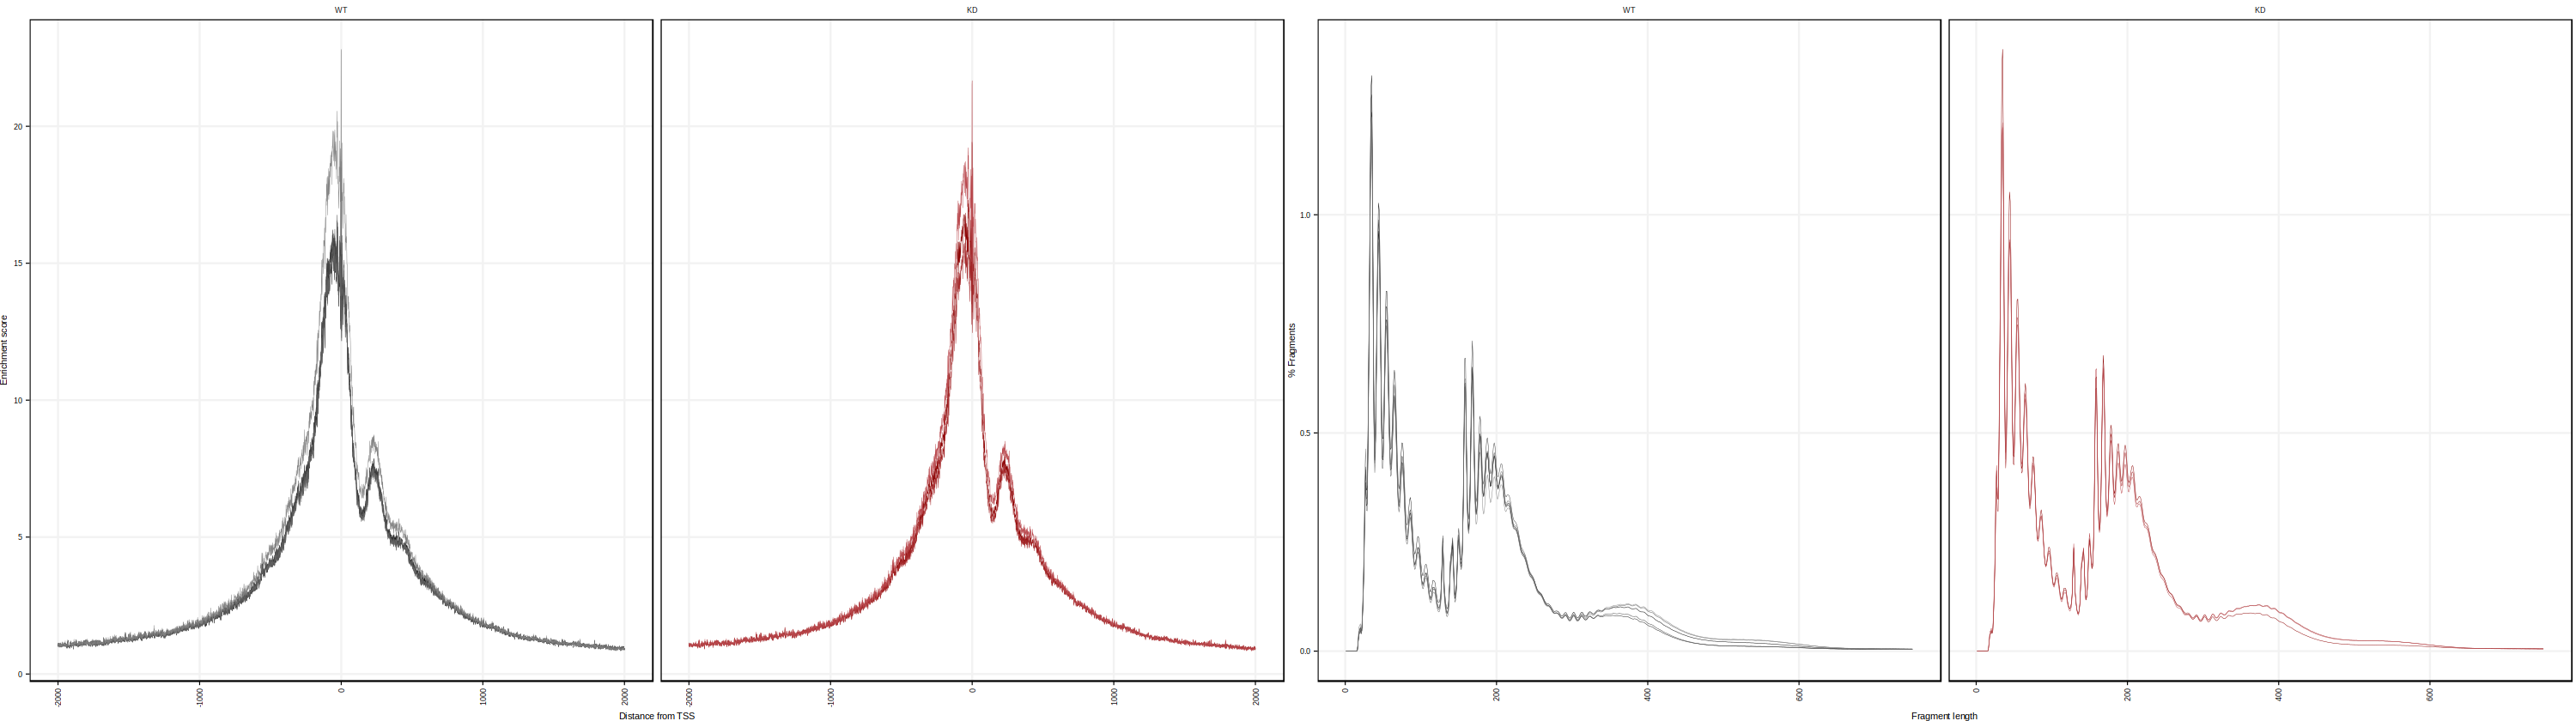

In [22]:
theme_atac = theme + theme(legend.position = 'none', 
         strip.background = element_blank(),
         strip.text = element_text(size = 5),
         axis.title = element_text(size = 6, color = 'black'),
         )


p_atac_tssE = ggplot(TSS[variable == 'normValue'], aes(x, value, color = sample_clean)) + 
    geom_line(linewidth = 0.1) + 
    # ggrepel::geom_text_repel(data = TSS[variable == 'normValue' & x == -60], 
    #                          aes(label = sample_clean),
    #                          #color = 'black', 
    #                          size = 5 * 0.35, 
    #                          box.padding = 1,
    #                          bg.color='white', 
    #                          bg.r = 0.1,
    #                         # nudge_x = 500,
    #                          direction = "x",
    #                          min.segment.length = 0,
    #                          segment.size = 0.3,
    #                          max.overlaps = 1,
    #                          seed = 1
    #                          ) + 
    scale_color_manual(values = sample_colors) +
    xlab('Distance from TSS') + ylab('Enrichment score') + 
    facet_wrap(~genotype) + 
    theme_atac

p_atac_fragments = ggplot(FragmentSize, aes(fragmentSize, fragmentPercent, color = sample_clean)) + 
    geom_line(linewidth = 0.1) + 
    # ggrepel::geom_text_repel(data = FragmentSize[fragmentSize == 35], 
    #                          aes(label = sample_clean),
    #                          #color = 'black', 
    #                          size = 5 * 0.35, 
    #                          box.padding = 0.25,
    #                          bg.color='white', 
    #                          bg.r = 0.1,
    #                          nudge_x = 300,
    #                          #direction = "x",
    #                          min.segment.length = 0,
    #                          segment.size = 0.3,
    #                          #max.overlaps = Inf,
    #                          seed = 1
    #                          ) + 
    scale_color_manual(values = sample_colors) +
    xlab('Fragment length') + ylab('% Fragments') + 
    facet_wrap(~genotype) + 
    theme_atac

io$archrvitro = file.path("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR")
archrvitro = suppressMessages(ArchR::loadArchRProject(io$archrvitro))
peak_stats = as.data.table(ArchR::getPeakSet(archrvitro)) %>% 
    .[,count := .N, by = 'peakType'] %>% unique(by = 'peakType')

p_peak_stats = ggplot(peak_stats, aes(peakType, count)) + 
    geom_bar(fill = 'black', stat = 'identity') + 
    ylab('# peaks') + 
    theme + theme(plot.margin = margin(15,0,0,0),
                          axis.title = element_text(size = 6, color = 'black'))

p2 = ggarrange(p_atac_tssE, p_atac_fragments, nrow = 1, align = 'hv', widths = c(1,1,0.25))
p2

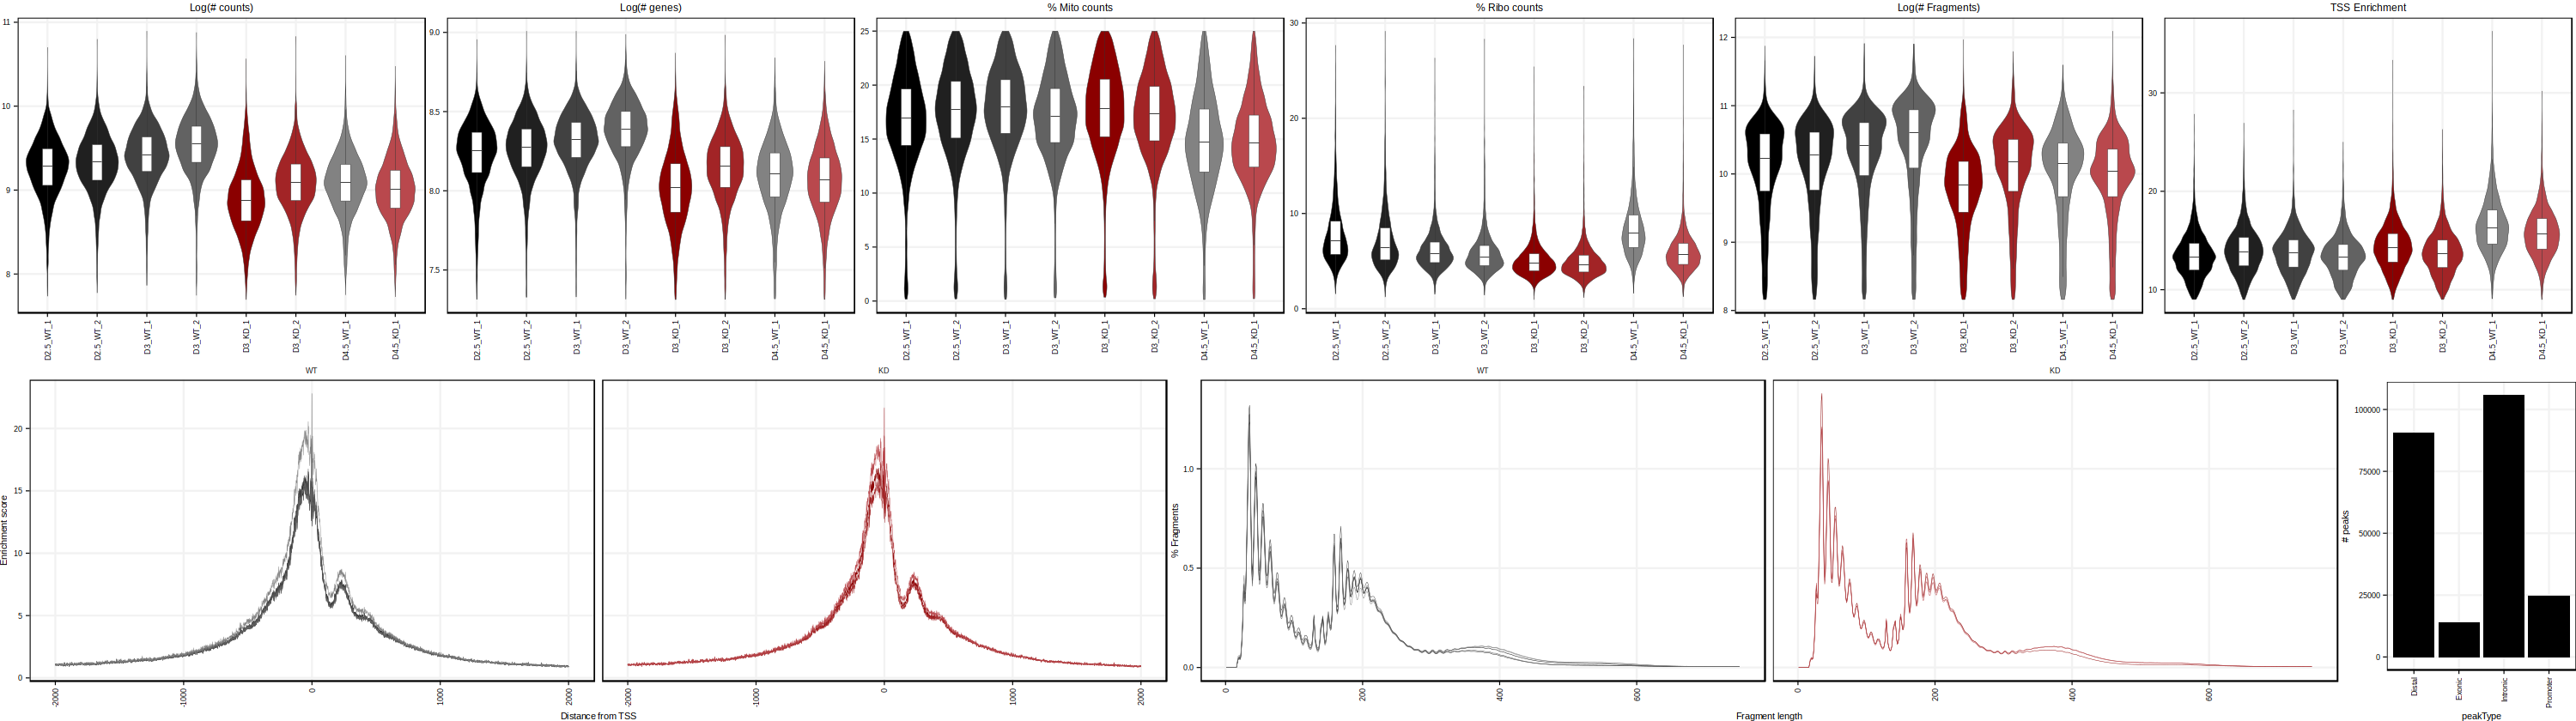

In [23]:
ggarrange(p1, ggarrange(p2,p_peak_stats, widths = c(1, 0.1)) , ncol = 1)

In [46]:
ggsave(file.path(io$basedir, 'thesis/qc/multiome_QC_metrics.pdf'), 
       plot = ggarrange(p1, ggarrange(p2,p_peak_stats, widths = c(1, 0.2)) , ncol = 1),
       width = 190, 
       height = 80, 
       units = "mm")

In [276]:
p1 = ggarrange(p_rna_reads, p_rna_genes, p_rna_mito, p_rna_ribo, p_atac_frags, p_atac_tss, nrow = 1, align = 'hv')
p2 = ggarrange(p_atac_tssE, p_atac_fragments, p_peak_stats, nrow = 1, align = 'hv', widths = c(1,1,0.25))


Warning message:
“Graphs cannot be vertically aligned unless the axis parameter is set. Placing graphs unaligned.”
Warning message:
“Graphs cannot be horizontally aligned unless the axis parameter is set. Placing graphs unaligned.”


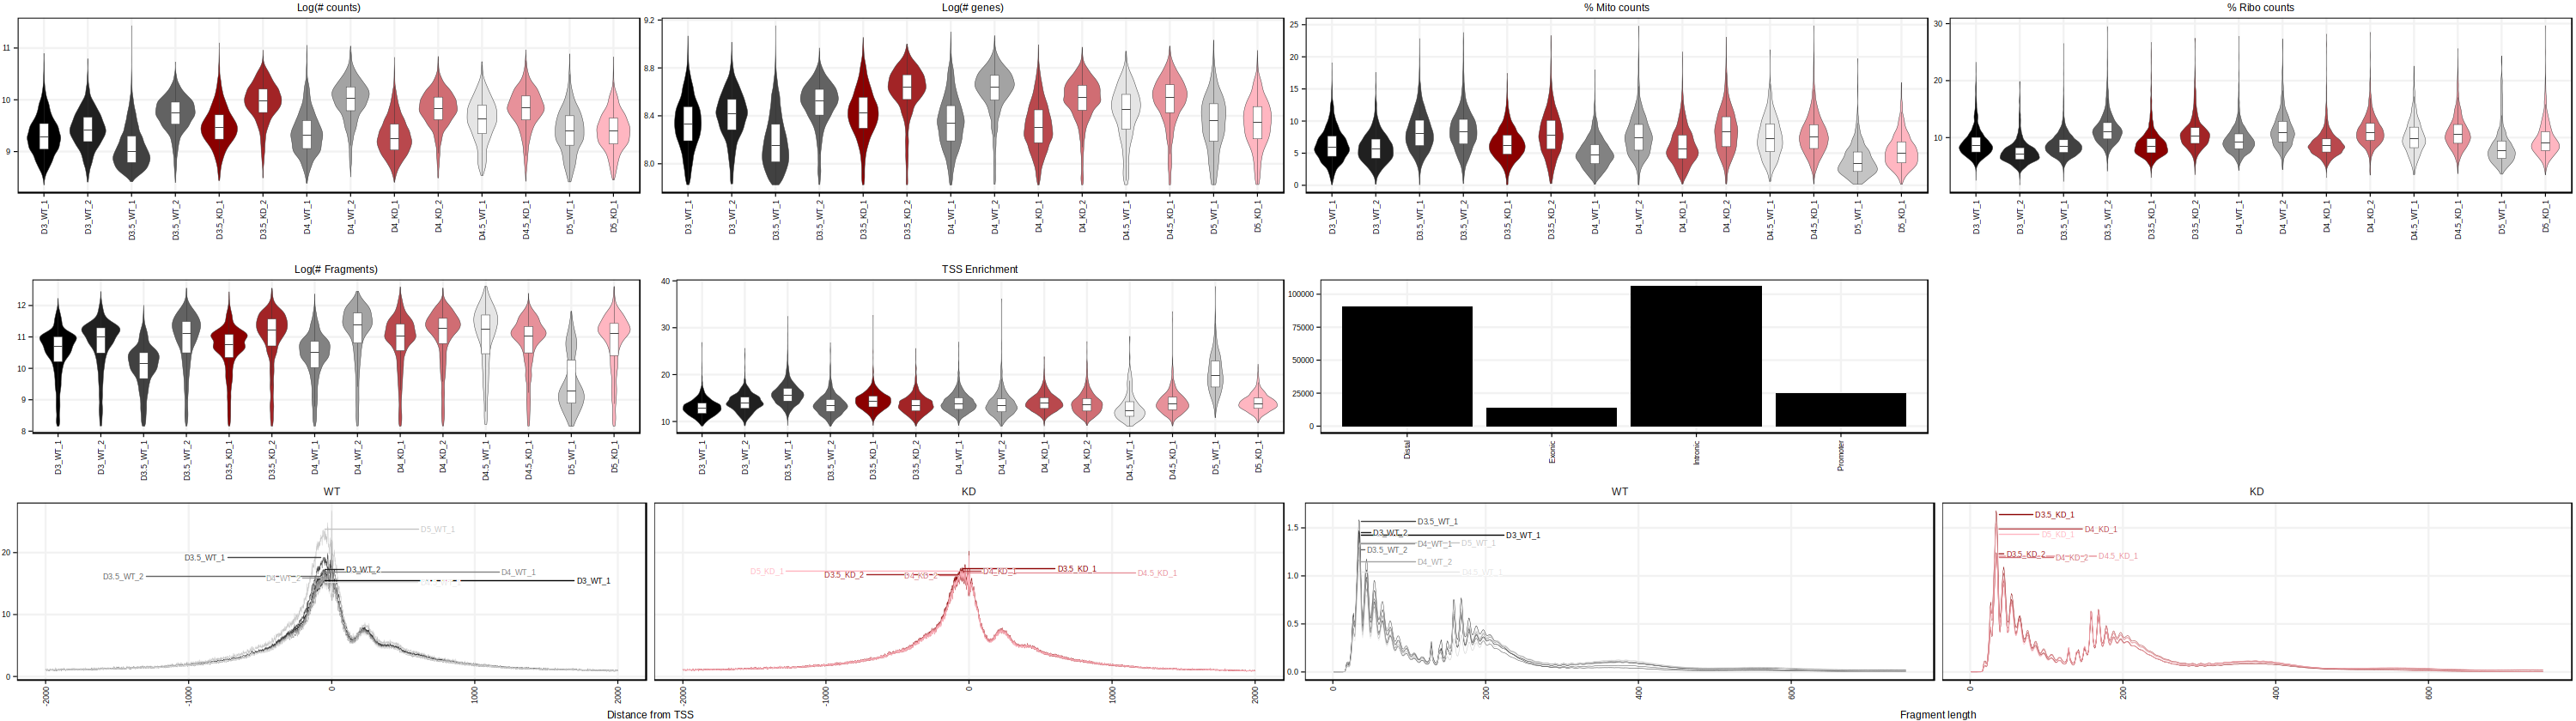

In [277]:
ggarrange(ggarrange(p_rna_reads, p_rna_genes, p_rna_mito, p_rna_ribo, nrow = 1, align = 'hv' ),
          ggarrange(p_atac_frags, p_atac_tss, p_peak_stats, NULL, nrow = 1, align = 'hv'),
          ggarrange(p_atac_tssE, p_atac_fragments, nrow = 1, align = 'hv'),
          ncol = 1, align = 'hv')

In [30]:
combined_metadata = fread(file.path(io$basedir, 'results/rna_atac/combined_metadata.txt.gz')) %>% 
    .[,sample_clean := sample_rename[match(sample, names(sample_rename))]] %>% 
    .[,sample_clean := factor(sample_clean, levels = sample_order)]

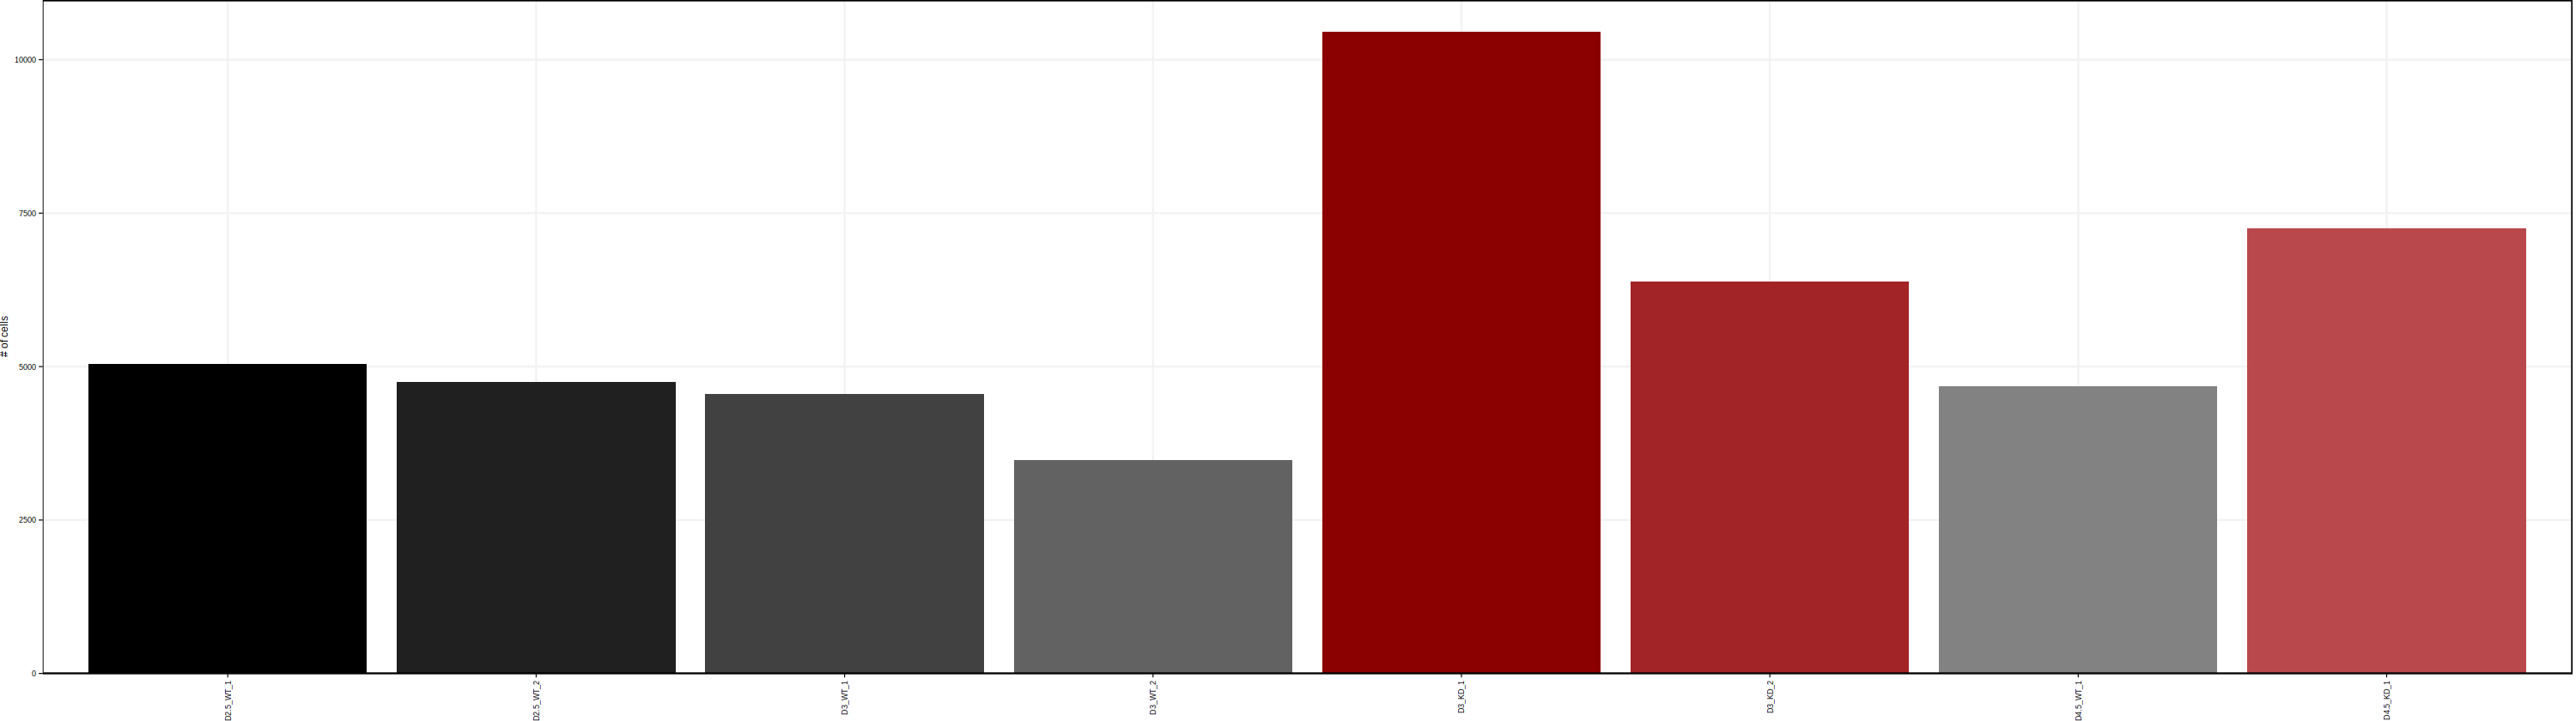

In [44]:
p3 = ggplot(combined_metadata, aes(sample_clean, fill = sample_clean)) + 
    geom_bar()+ 
    scale_fill_manual(values = sample_colors)  +
    scale_y_continuous(expand = c(0,0,0.05,0), name = '# of cells') +
    theme + 
    theme(axis.title.y = element_text(size = 7))
p3

In [47]:
ggsave(file.path(io$basedir, 'thesis/qc/multiome_QC_cellnrs.pdf'), 
       plot = p3,
       width = 30, 
       height = 40, 
       units = "mm")